## **Modelos Deep Learning em PyTorch**

**Tarefa 3 do Trabalho Prático — Aprendizagem Profunda**

1. **DNNs** — Feedforward com features tabulares, variando largura
2. **Embedding + DNN** — Embedding treinável, variando dimensão do embedding
3. **BiLSTM** — LSTM bidirecional, variando dimensão do hidden state
4. **BiGRU** — Alternativa ao LSTM (comparação LSTM vs GRU)
5. **BiLSTM + GloVe** — Embeddings pré-treinados, frozen vs fine-tuned
6. **Stratified K-Fold (K=5)** — Comparação robusta
7. **Retreino e avaliação final** no dataset do professor

### **1. Imports e Configuração**

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time, re
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

sys.path.append(os.path.abspath('../src'))
from utils import (prepare_text_data, prepare_fold_data, transform_new_texts,
                    clean_text, stratified_k_fold)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Dispositivo: cuda


### **2. Carregamento dos Dados**

In [4]:
print('A carregar os datasets...')

df_main = pd.read_csv('../database/dataset.csv', sep=';')
df_main.columns = df_main.columns.str.lower()
textos = df_main['text'].tolist()
labels = df_main['label'].tolist()

df_test = pd.read_csv('../database/dataset-test.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

class_names_list = sorted(set(labels))
num_classes = len(class_names_list)

print(f'  Dataset principal: {len(textos)} textos')
print(f'  Dataset teste (prof): {len(textos_test)} textos')
print(f'  Classes: {class_names_list}')

A carregar os datasets...
  Dataset principal: 122835 textos
  Dataset teste (prof): 475 textos
  Classes: ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']


### **3. Definição dos Modelos**

Cada família tem duas variantes, explorando o hiperparâmetro mais relevante:

| Família | Variantes | Hiperparâmetro explorado |
|---------|-----------|--------------------------|
| **DNN (tabular)** | Wide (256→128), Narrow (128→64), Deep (256→128→64) | Largura e profundidade |
| **DNN (ativação)** | ReLU vs LeakyReLU vs ELU (256→128) | Função de ativação |
| **Embedding + DNN** | embed 128d, embed 256d | Dimensão do embedding |
| **BiLSTM** | hidden 128, hidden 256 | Dimensão do hidden state |
| **BiGRU** | hidden 128, hidden 256 | LSTM vs GRU + hidden size |
| **BiLSTM + GloVe** | frozen, fine-tuned | Congelar vs ajustar embeddings |

Todos os modelos sequenciais usam o mesmo classificador (128→64→classes) para comparação justa.

In [5]:
# DNNs tabulares 

class DNNWide(nn.Module):
    """256 → 128 → classes"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes))
    def forward(self, x): return self.net(x)

class DNNNarrow(nn.Module):
    """128 → 64 → classes"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, num_classes))
    def forward(self, x): return self.net(x)

# Embedding + DNN — varia dimensão do embedding
# Classificador fixo: 128 → 64 → classes

class EmbeddingDNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, num_classes))
    def forward(self, x):
        embedded = self.embedding(x)
        mask = (x != 0).unsqueeze(-1).float()
        pooled = (embedded * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.net(pooled)

# BiLSTM — varia hidden_dim

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(combined))

# BiGRU — alternativa ao LSTM, varia hidden_dim

class BiGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, hidden = self.gru(embedded)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(combined))

# BiLSTM + GloVe — varia frozen vs fine-tuned

class BiLSTMGloVe(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, freeze_embed=True):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.freeze_embed = freeze_embed
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_embed, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, num_classes))
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(combined))

class DNNDeep(nn.Module):
    """256 → 128 → 64 → classes (mais profunda, ReLU)"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes))
    def forward(self, x): return self.net(x)
class DNNLeakyReLU(nn.Module):
    """256 → 128 → classes (LeakyReLU)"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.1), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.LeakyReLU(0.1), nn.Dropout(0.4),
            nn.Linear(128, num_classes))
    def forward(self, x): return self.net(x)
class DNNELU(nn.Module):
    """256 → 128 → classes (ELU)"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.ELU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ELU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes))
    def forward(self, x): return self.net(x)

class DNNSimple(nn.Module):
    """128 → 32 → classes (simples, ReLU + Dropout)"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 32), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(32, num_classes))
    def forward(self, x): return self.net(x)

class DNNVeryDeep(nn.Module):
    """256 → 128 → 64 → 32 → classes"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, num_classes))
    def forward(self, x): return self.net(x)


print('Modelos definidos.')

Modelos definidos.


### **4. Validação Cruzada — Stratified K-Fold (K=5)**

Para cada fold, TF-IDF e vocabulários são ajustados apenas no treino.

In [6]:
K = 3
FEAT_PARAMS = dict(max_features=3000, char_features=2000, ngram_range=(1, 2), stop_words=set())
EMBED_DIM_DEFAULT = 128  
HIDDEN_DIM_DEFAULT = 128
MAX_SEQ_LEN = 150
VOCAB_SIZE = 30000  
GLOVE_DIM = 100
GLOVE_HIDDEN = 128

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return [t for t in text.split() if len(t) > 1]

def texts_to_sequences(texts, word2idx, max_len):
    seqs = []
    for text in texts:
        tokens = simple_tokenize(text)
        seq = [word2idx.get(t, 1) for t in tokens[:max_len]]
        seqs.append(seq + [0] * (max_len - len(seq)))
    return np.array(seqs)

def build_fold_vocab(texts_tr):
    wc = Counter()
    for t in texts_tr: wc.update(simple_tokenize(t))
    mc = wc.most_common(VOCAB_SIZE - 2)
    w2i = {w: i+2 for i, (w, _) in enumerate(mc)}
    w2i['<PAD>'] = 0; w2i['<UNK>'] = 1
    return w2i

def train_pytorch(model, X_tr, y_tr, X_vl, y_vl,
                  epochs=60, lr=0.001, wd=1e-3, patience=10, bs=256):
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=5)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=bs, shuffle=True)
    best_vl = float('inf'); wait = 0; best_st = None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for ep in range(epochs):
        model.train()
        ep_loss = 0; ep_correct = 0; ep_total = 0
        for bx, by in loader:
            opt.zero_grad()
            out = model(bx)
            loss = crit(out, by)
            loss.backward(); opt.step()
            ep_loss += loss.item() * bx.size(0)
            ep_correct += (torch.argmax(out, 1) == by).sum().item()
            ep_total += bx.size(0)
        history['train_loss'].append(ep_loss / ep_total)
        history['train_acc'].append(ep_correct / ep_total)
        model.eval()
        val_loader = DataLoader(TensorDataset(X_vl, y_vl), batch_size=bs, shuffle=False)
        vl_loss = 0; vl_correct = 0; vl_total = 0
        with torch.no_grad():
            for bx, by in val_loader:
                out = model(bx)
                vl_loss += crit(out, by).item() * bx.size(0)
                vl_correct += (torch.argmax(out, 1) == by).sum().item()
                vl_total += bx.size(0)
        vl = vl_loss / vl_total
        va = vl_correct / vl_total
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        sched.step(vl)
        if vl < best_vl:
            best_vl = vl; wait = 0
            best_st = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_st: model.load_state_dict(best_st)
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for bx, by in DataLoader(TensorDataset(X_vl, y_vl), batch_size=bs, shuffle=False):
            correct += (torch.argmax(model(bx), 1) == by).sum().item()
            total += bx.size(0)
    final_acc = correct / total
    return final_acc, history

def plot_training_curves(nome, all_histories):
    """Plota curvas de treino médias dos K folds."""
    min_len = min(len(h['train_loss']) for h in all_histories)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for (tk, vk), ax, title in [
        (('train_loss', 'val_loss'), axes[0], 'Loss'),
        (('train_acc', 'val_acc'), axes[1], 'Accuracy')
    ]:
        t_vals = np.array([h[tk][:min_len] for h in all_histories])
        v_vals = np.array([h[vk][:min_len] for h in all_histories])
        epochs_range = range(1, min_len + 1)
        ax.plot(epochs_range, t_vals.mean(axis=0), label='Train', linewidth=2)
        ax.plot(epochs_range, v_vals.mean(axis=0), label='Val', linewidth=2)
        ax.fill_between(epochs_range,
                        t_vals.mean(0) - t_vals.std(0),
                        t_vals.mean(0) + t_vals.std(0), alpha=0.15)
        ax.fill_between(epochs_range,
                        v_vals.mean(0) - v_vals.std(0),
                        v_vals.mean(0) + v_vals.std(0), alpha=0.15)
        ax.set_xlabel('Epoch'); ax.set_ylabel(title)
        ax.set_title(f'{nome} — {title}')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
def kfold_seq(nome, model_fn):
    print(f'\n{nome}:')
    accs = []; histories = []
    for fold, (tr_i, vl_i) in enumerate(stratified_k_fold(labels, K)):
        t_tr = [textos[i] for i in tr_i]; t_vl = [textos[i] for i in vl_i]
        l_tr = [labels[i] for i in tr_i]; l_vl = [labels[i] for i in vl_i]
        w2i = build_fold_vocab(t_tr); vs = len(w2i)
        s_tr = texts_to_sequences(t_tr, w2i, MAX_SEQ_LEN)
        s_vl = texts_to_sequences(t_vl, w2i, MAX_SEQ_LEN)
        y_tr = np.array([class_names_list.index(l) for l in l_tr])
        y_vl = np.array([class_names_list.index(l) for l in l_vl])
        torch.manual_seed(42)
        acc, hist = train_pytorch(
            model_fn(vs, num_classes),
            torch.LongTensor(s_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.LongTensor(s_vl).to(device), torch.LongTensor(y_vl).to(device),
            wd=1e-4, patience=10)
        accs.append(acc); histories.append(hist)
        print(f'  Fold {fold+1}: {acc:.2%}')
    cv_results[nome] = np.array(accs)
    print(f'  → {np.mean(accs):.2%} ± {np.std(accs):.2%}')
    plot_training_curves(nome, histories)

print('Funções definidas.')

Funções definidas.


In [7]:
import zipfile, urllib.request
GLOVE_DIR = './data/vectors/glove'
GLOVE_PATH = os.path.join(GLOVE_DIR, f'glove.6B.{GLOVE_DIM}d.txt')
if not os.path.exists(GLOVE_PATH):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    zip_path = os.path.join(GLOVE_DIR, 'glove.6B.zip')
    if not os.path.exists(zip_path):
        print('A descarregar GloVe 6B (822MB)...')
        urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', zip_path)
    print('A extrair...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract(f'glove.6B.{GLOVE_DIM}d.txt', GLOVE_DIR)
else:
    print(f'GloVe já disponível em {GLOVE_PATH}')
print(f'A carregar GloVe {GLOVE_DIM}d...')
glove_all = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        glove_all[parts[0]] = np.array(parts[1:], dtype=np.float32)
print(f'✅ GloVe: {len(glove_all)} vetores')

def build_emb_matrix(w2i, glove, dim):
    mat = np.random.normal(scale=0.6, size=(len(w2i), dim))
    mat[0] = 0; found = 0
    for w, i in w2i.items():
        if w in glove: mat[i] = glove[w]; found += 1
    return mat, found

GloVe já disponível em ./data/vectors/glove\glove.6B.100d.txt
A carregar GloVe 100d...
✅ GloVe: 400000 vetores


Stratified k-Fold Cross-Validation

DNN Wide (256→128):
  Fold 1: 94.69%
  Fold 2: 94.91%
  Fold 3: 94.71%
  → 94.77% ± 0.10%


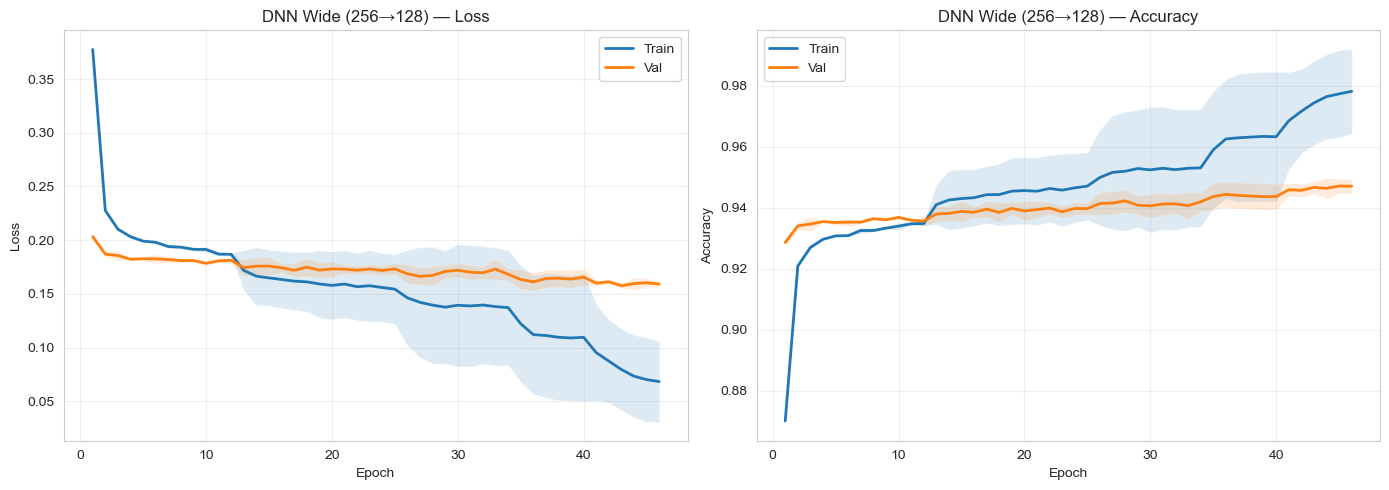


DNN Narrow (128→64):
  Fold 1: 94.76%
  Fold 2: 94.67%
  Fold 3: 94.60%
  → 94.68% ± 0.07%


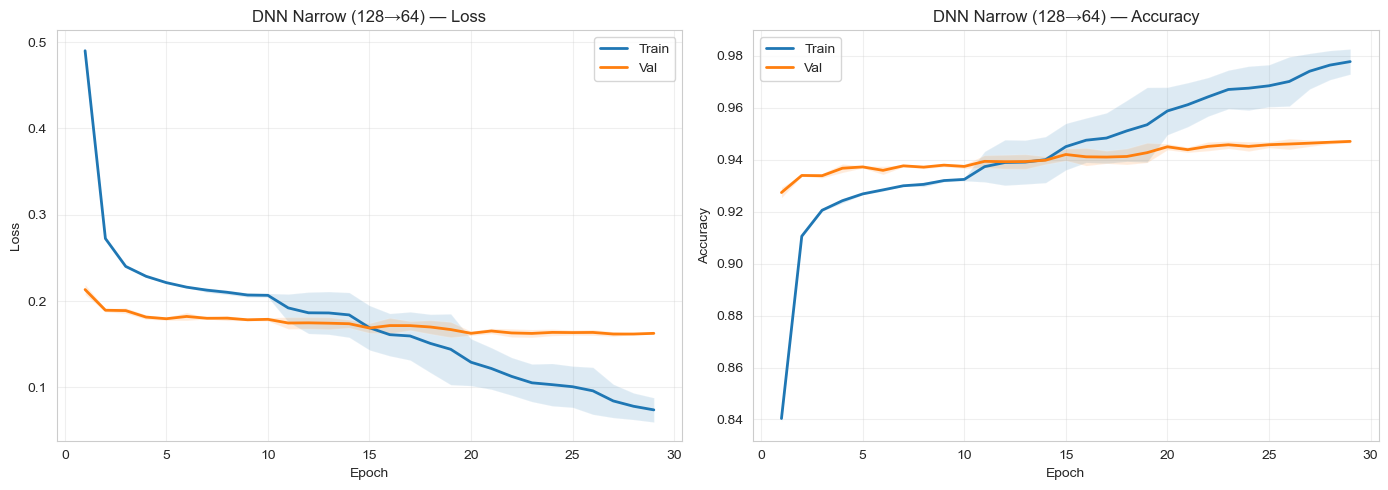


DNN Deep (256→128→64):
  Fold 1: 94.74%
  Fold 2: 94.60%
  Fold 3: 94.73%
  → 94.69% ± 0.06%


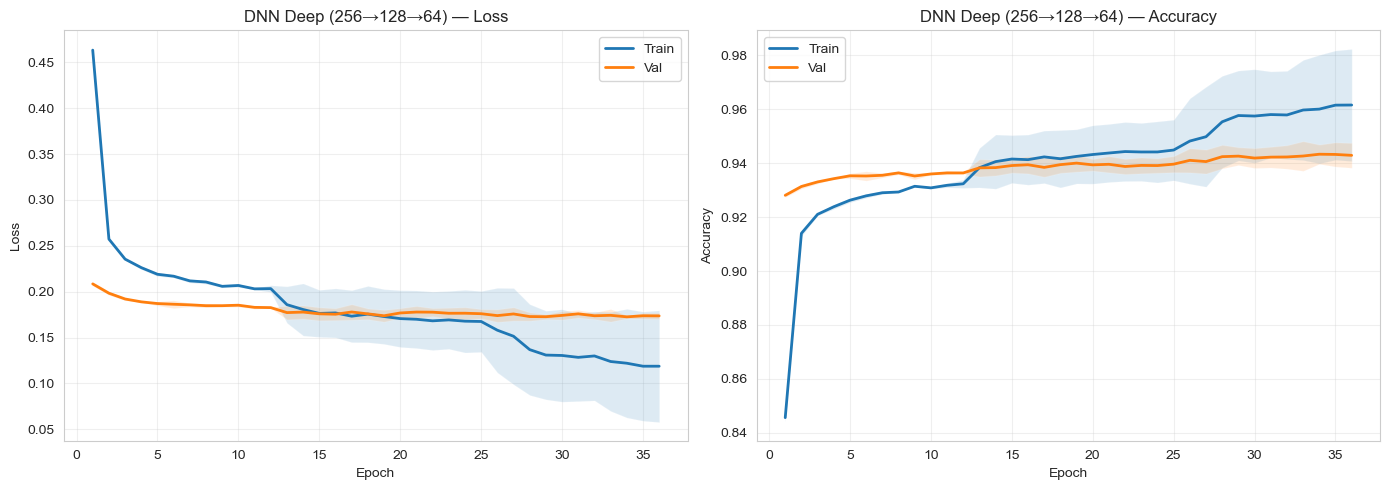


DNN Simple (128→32):
  Fold 1: 94.61%
  Fold 2: 94.40%
  Fold 3: 94.38%
  → 94.46% ± 0.11%


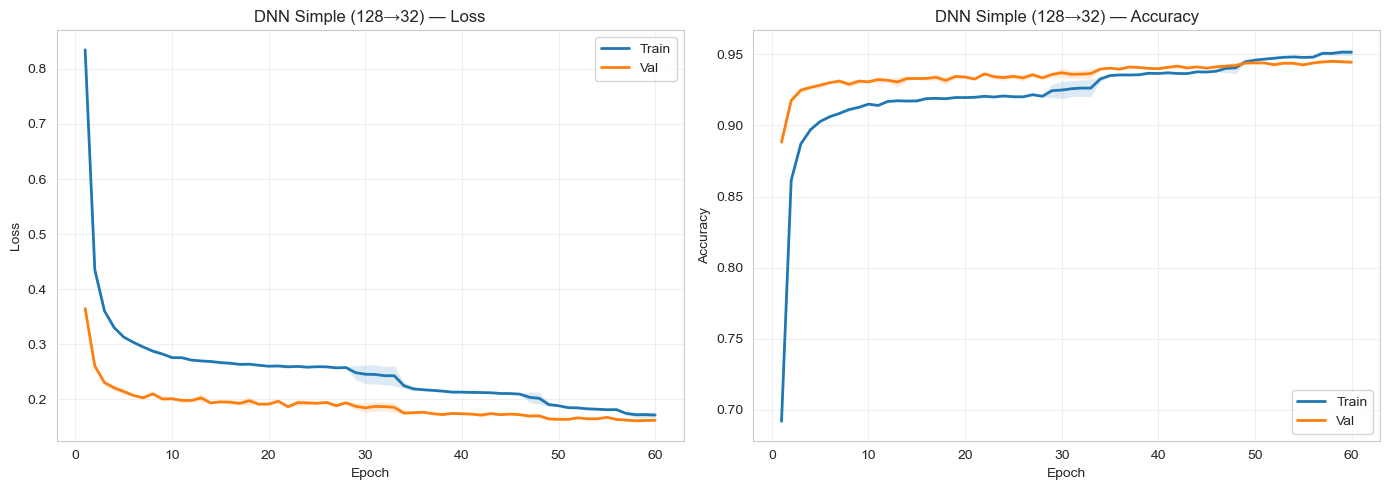


DNN VeryDeep (256→128→64→32):
  Fold 1: 94.35%
  Fold 2: 94.16%
  Fold 3: 94.33%
  → 94.28% ± 0.08%


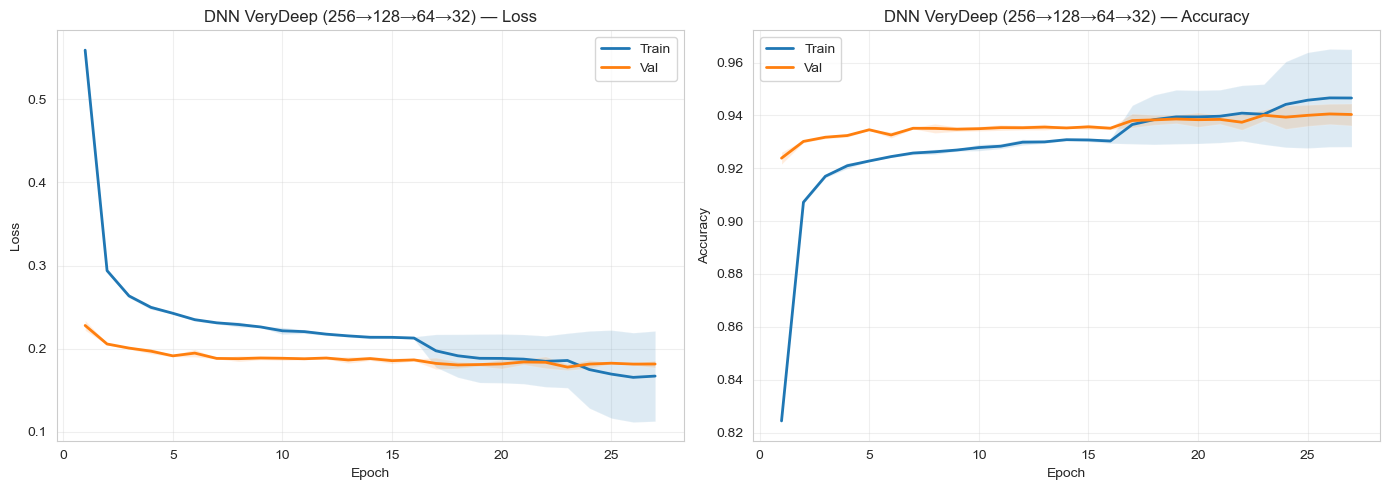


DNN LeakyReLU (256→128):
  Fold 1: 94.75%
  Fold 2: 94.64%
  Fold 3: 94.76%
  → 94.71% ± 0.05%


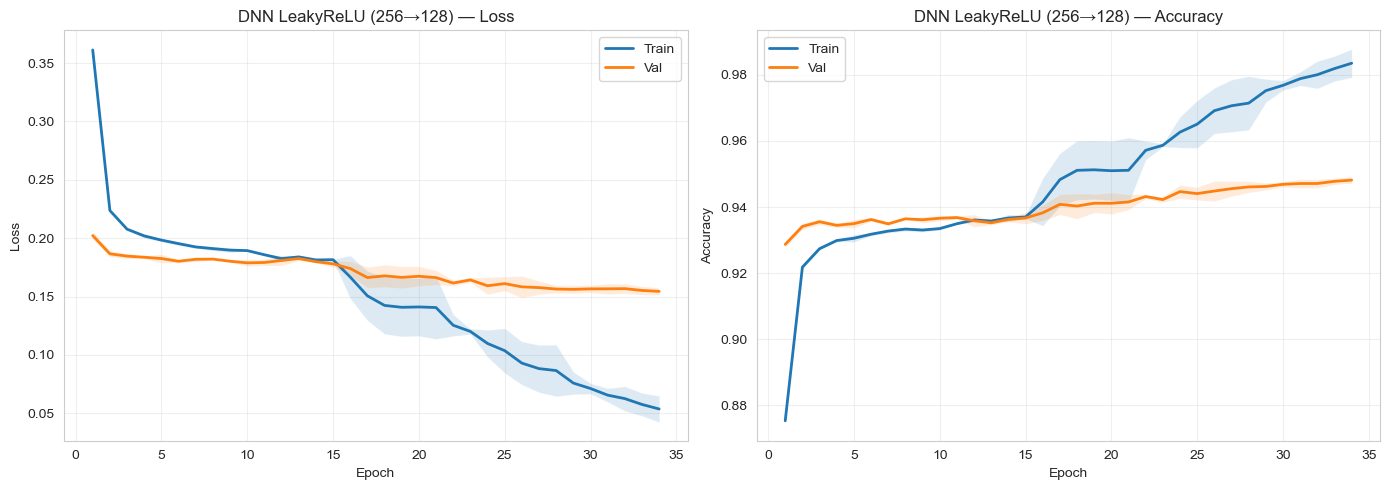


DNN ELU (256→128):
  Fold 1: 94.38%
  Fold 2: 94.28%
  Fold 3: 94.32%
  → 94.32% ± 0.04%


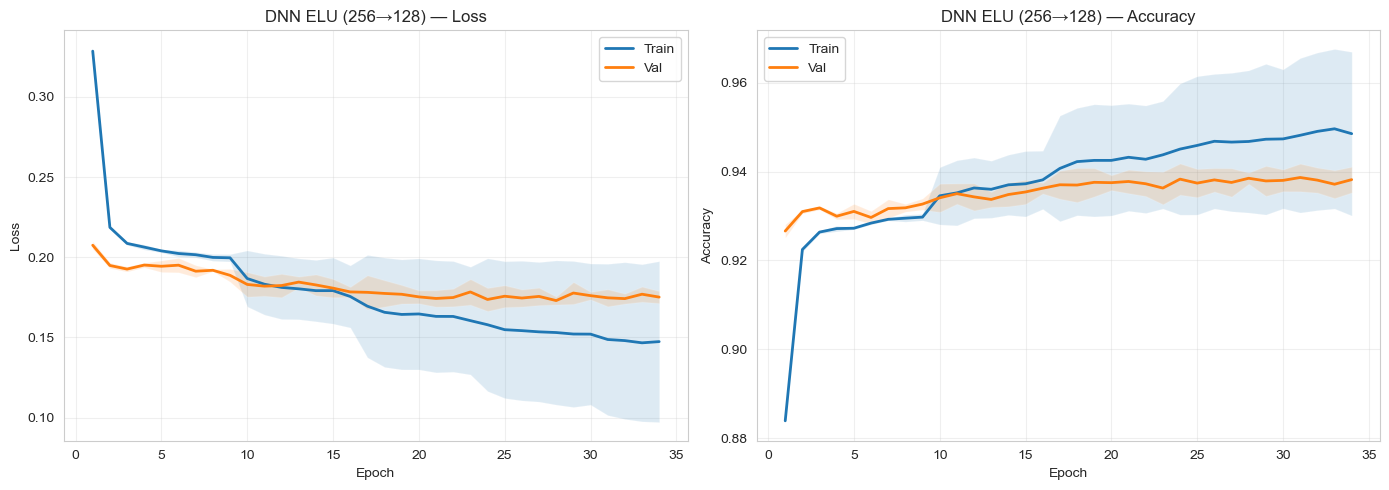


Embed+DNN (128d):
  Fold 1: 91.19%
  Fold 2: 90.91%
  Fold 3: 90.61%
  → 90.90% ± 0.24%


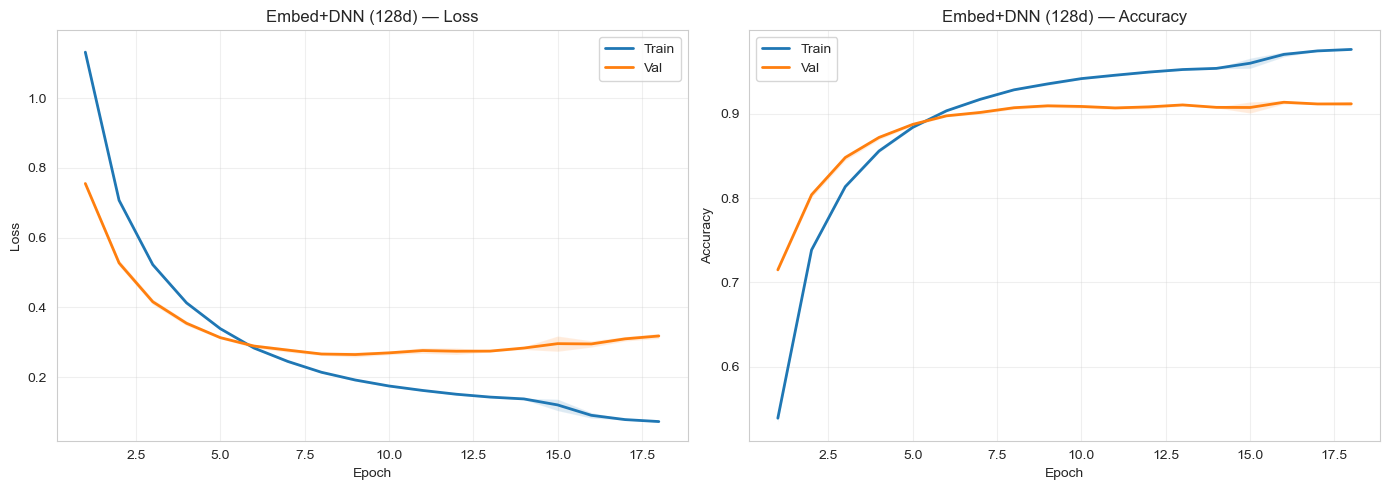


Embed+DNN (256d):
  Fold 1: 90.84%
  Fold 2: 90.67%
  Fold 3: 90.56%
  → 90.69% ± 0.12%


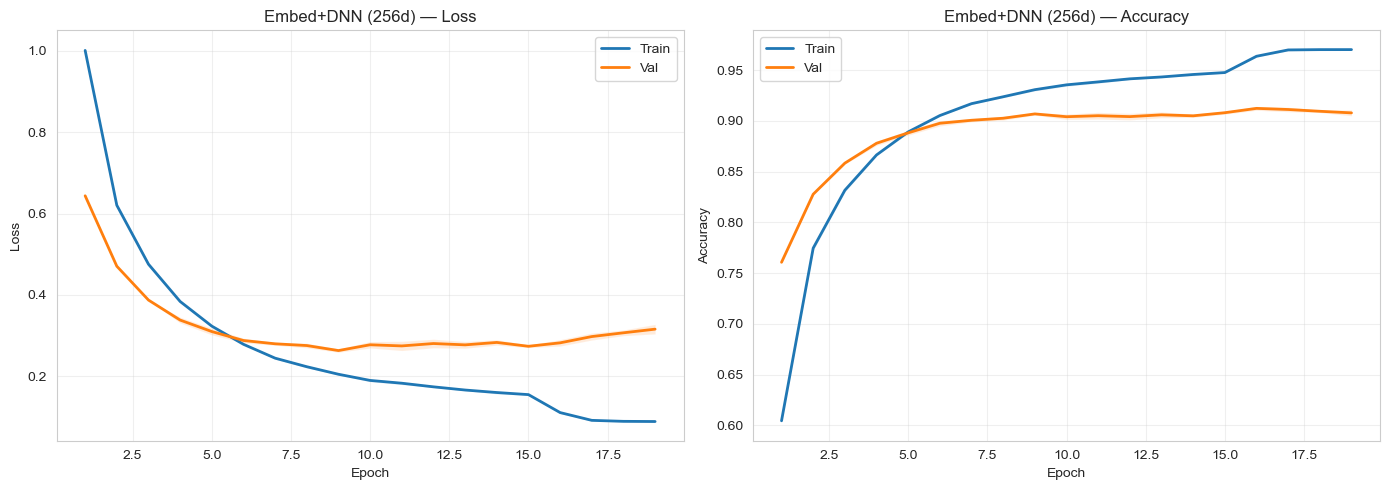


BiLSTM (h=128):
  Fold 1: 94.19%
  Fold 2: 94.06%
  Fold 3: 94.18%
  → 94.14% ± 0.06%


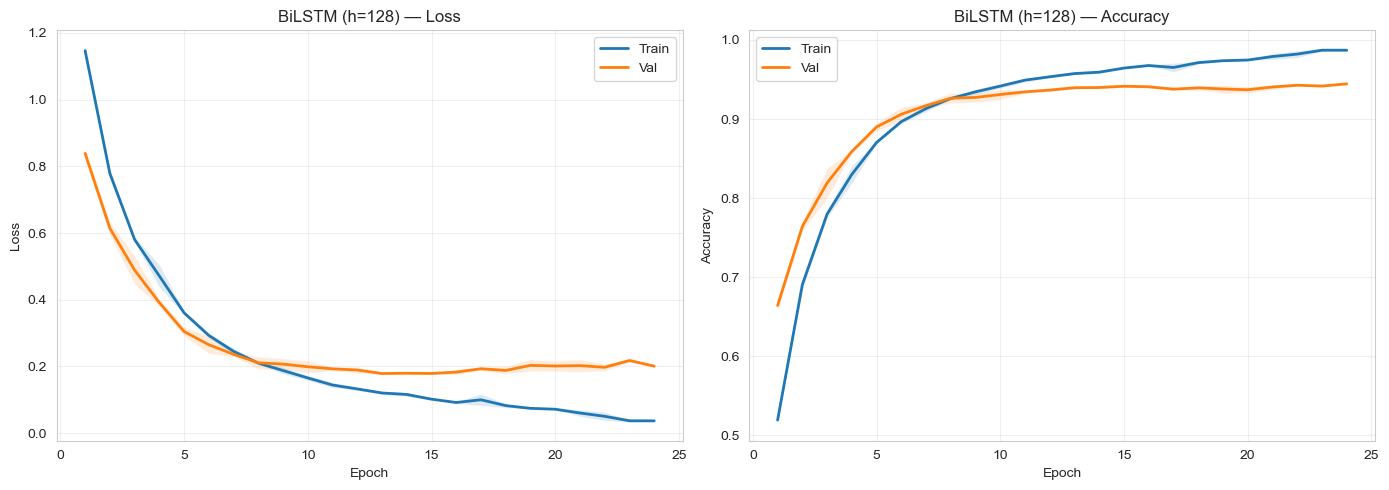


BiLSTM (h=256):
  Fold 1: 94.11%
  Fold 2: 94.18%
  Fold 3: 94.04%
  → 94.11% ± 0.06%


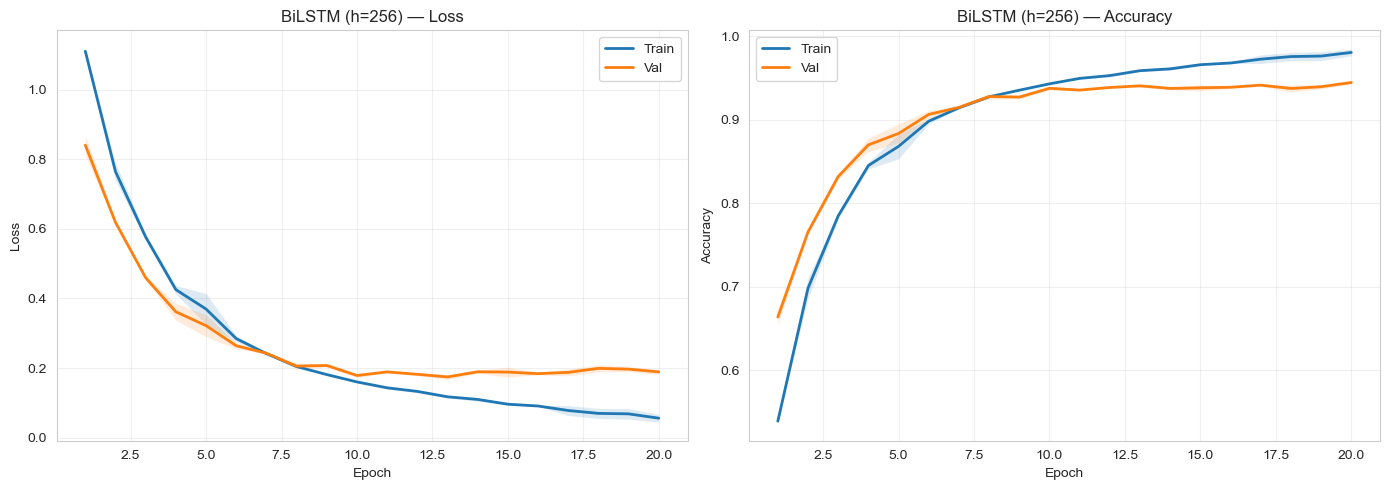


BiGRU (h=128):
  Fold 1: 94.34%
  Fold 2: 94.53%
  Fold 3: 94.60%
  → 94.49% ± 0.11%


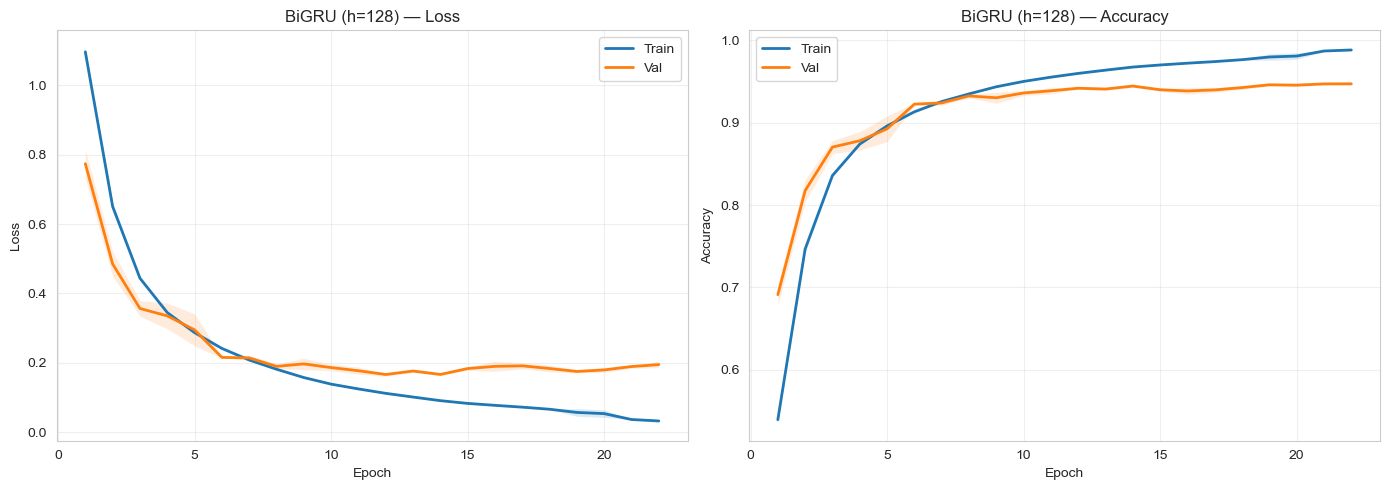


BiGRU (h=256):
  Fold 1: 94.91%
  Fold 2: 94.61%
  Fold 3: 94.63%
  → 94.72% ± 0.13%


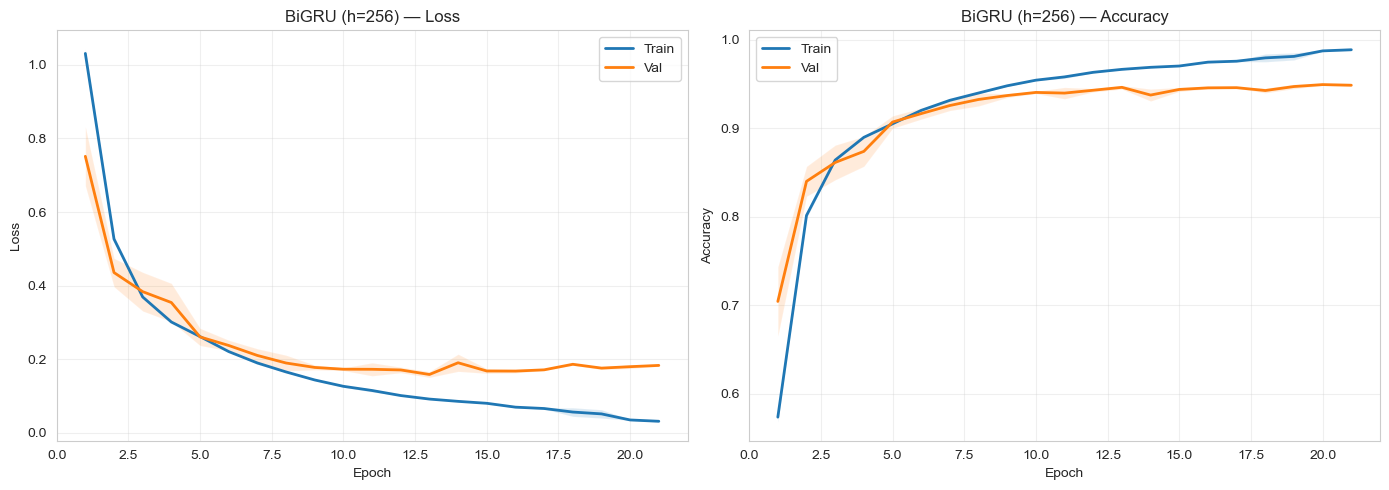


BiLSTM+GloVe (frozen):
    GloVe: 27168/29998
  Fold 1: 93.94%
  Fold 2: 93.85%
  Fold 3: 93.54%
  → 93.78% ± 0.17%


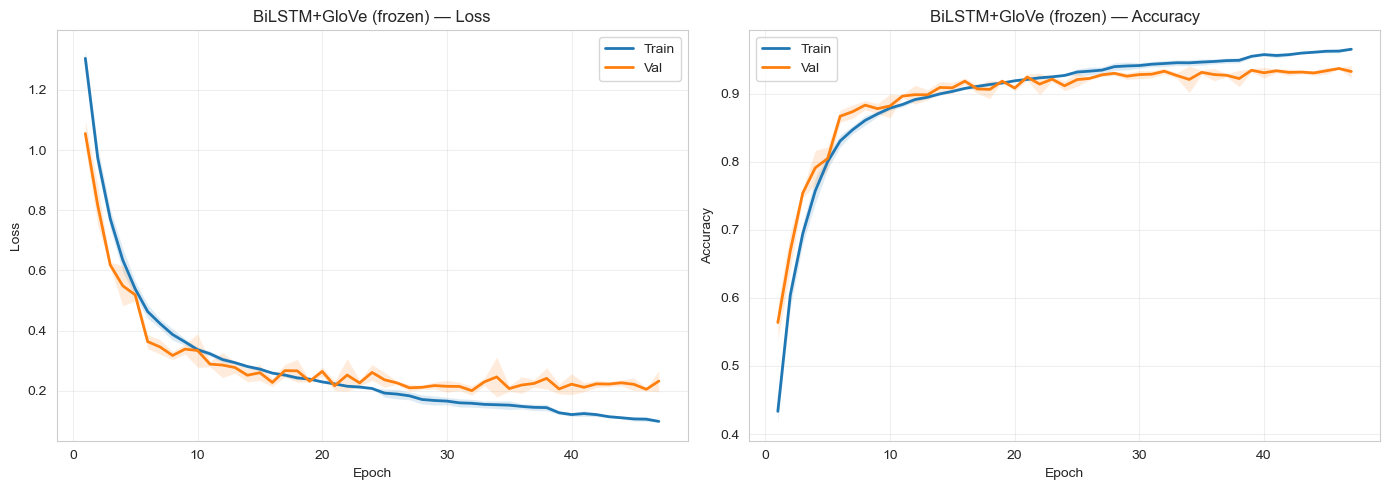


BiLSTM+GloVe (fine-tuned):
    GloVe: 27168/29998
  Fold 1: 93.48%
  Fold 2: 93.38%
  Fold 3: 93.33%
  → 93.40% ± 0.06%


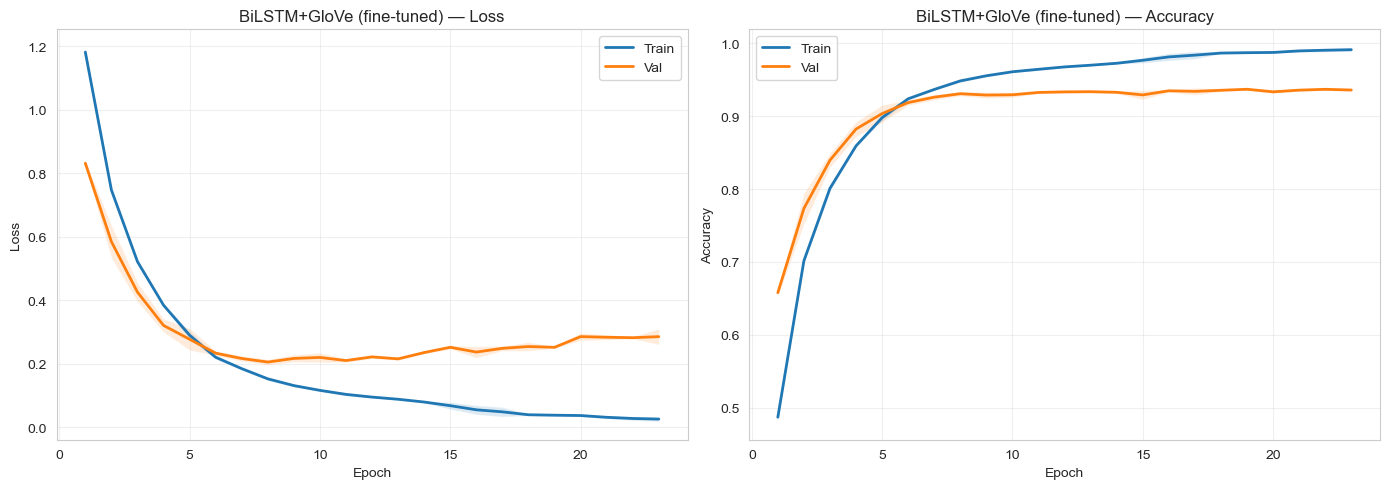

In [13]:
print("Stratified k-Fold Cross-Validation")
cv_results = {}

# DNNs tabulares 
tab_cfgs = {
    'DNN Wide (256→128)':          lambda i, n: DNNWide(i, n),
    'DNN Narrow (128→64)':         lambda i, n: DNNNarrow(i, n),
    'DNN Deep (256→128→64)':       lambda i, n: DNNDeep(i, n),
    'DNN Simple (128→32)':         lambda i, n: DNNSimple(i, n),
    'DNN VeryDeep (256→128→64→32)':lambda i, n: DNNVeryDeep(i, n),
    'DNN LeakyReLU (256→128)':     lambda i, n: DNNLeakyReLU(i, n),
    'DNN ELU (256→128)':           lambda i, n: DNNELU(i, n),
}
for nome, fn in tab_cfgs.items():
    print(f'\n{nome}:')
    accs = []; histories = []
    for fold, (tr_i, vl_i) in enumerate(stratified_k_fold(labels, K)):
        t_tr = [textos[i] for i in tr_i]; t_vl = [textos[i] for i in vl_i]
        l_tr = [labels[i] for i in tr_i]; l_vl = [labels[i] for i in vl_i]
        X_tr, _, X_vl, _, _, _ = prepare_fold_data(t_tr, l_tr, t_vl, l_vl, **FEAT_PARAMS)
        y_tr = np.array([class_names_list.index(l) for l in l_tr])
        y_vl = np.array([class_names_list.index(l) for l in l_vl])
        torch.manual_seed(42)
        acc, hist = train_pytorch(fn(X_tr.shape[1], num_classes),
            torch.FloatTensor(X_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.FloatTensor(X_vl).to(device), torch.LongTensor(y_vl).to(device))
        accs.append(acc); histories.append(hist)
        print(f'  Fold {fold+1}: {acc:.2%}')
    cv_results[nome] = np.array(accs)
    print(f'  → {np.mean(accs):.2%} ± {np.std(accs):.2%}')
    plot_training_curves(nome, histories)

# Embedding+DNN 
kfold_seq('Embed+DNN (128d)', lambda vs, nc: EmbeddingDNN(vs, 128, nc))
kfold_seq('Embed+DNN (256d)', lambda vs, nc: EmbeddingDNN(vs, 256, nc))

# BiLSTM 
kfold_seq('BiLSTM (h=128)', lambda vs, nc: BiLSTM(vs, 128, 128, nc))
kfold_seq('BiLSTM (h=256)', lambda vs, nc: BiLSTM(vs, 128, 256, nc))

# BiGRU
kfold_seq('BiGRU (h=128)', lambda vs, nc: BiGRU(vs, 128, 128, nc))
kfold_seq('BiGRU (h=256)', lambda vs, nc: BiGRU(vs, 128, 256, nc))

# BiLSTM+GloVe
for nome, freeze in [('BiLSTM+GloVe (frozen)', True), ('BiLSTM+GloVe (fine-tuned)', False)]:
    print(f'\n{nome}:')
    accs = []; histories = []
    for fold, (tr_i, vl_i) in enumerate(stratified_k_fold(labels, K)):
        t_tr = [textos[i] for i in tr_i]; t_vl = [textos[i] for i in vl_i]
        l_tr = [labels[i] for i in tr_i]; l_vl = [labels[i] for i in vl_i]
        w2i = build_fold_vocab(t_tr)
        emb, found = build_emb_matrix(w2i, glove_all, GLOVE_DIM)
        if fold == 0: print(f'    GloVe: {found}/{len(w2i)-2}')
        s_tr = texts_to_sequences(t_tr, w2i, MAX_SEQ_LEN)
        s_vl = texts_to_sequences(t_vl, w2i, MAX_SEQ_LEN)
        y_tr = np.array([class_names_list.index(l) for l in l_tr])
        y_vl = np.array([class_names_list.index(l) for l in l_vl])
        torch.manual_seed(42)
        acc, hist = train_pytorch(
            BiLSTMGloVe(emb, GLOVE_HIDDEN, num_classes, freeze_embed=freeze),
            torch.LongTensor(s_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.LongTensor(s_vl).to(device), torch.LongTensor(y_vl).to(device),
            wd=1e-4, patience=15, bs=256)
        accs.append(acc); histories.append(hist)
        print(f'  Fold {fold+1}: {acc:.2%}')
    cv_results[nome] = np.array(accs)
    print(f'  → {np.mean(accs):.2%} ± {np.std(accs):.2%}')
    plot_training_curves(nome, histories)


In [14]:
rows = []
for nome, accs in cv_results.items():
    rows.append({'Modelo': nome, 'Média': f'{accs.mean():.2%}',
                 'Std': f'±{accs.std():.2%}', 'Min': f'{accs.min():.2%}', 'Max': f'{accs.max():.2%}'})
df_cv = pd.DataFrame(rows).sort_values('Média', ascending=False)
print('Resumo K-Fold CV')
print(df_cv.to_string(index=False))

Resumo K-Fold CV
                      Modelo  Média    Std    Min    Max
          DNN Wide (256→128) 94.77% ±0.10% 94.69% 94.91%
               BiGRU (h=256) 94.72% ±0.13% 94.61% 94.91%
     DNN LeakyReLU (256→128) 94.71% ±0.05% 94.64% 94.76%
       DNN Deep (256→128→64) 94.69% ±0.06% 94.60% 94.74%
         DNN Narrow (128→64) 94.68% ±0.07% 94.60% 94.76%
               BiGRU (h=128) 94.49% ±0.11% 94.34% 94.60%
         DNN Simple (128→32) 94.46% ±0.11% 94.38% 94.61%
           DNN ELU (256→128) 94.32% ±0.04% 94.28% 94.38%
DNN VeryDeep (256→128→64→32) 94.28% ±0.08% 94.16% 94.35%
              BiLSTM (h=128) 94.14% ±0.06% 94.06% 94.19%
              BiLSTM (h=256) 94.11% ±0.06% 94.04% 94.18%
       BiLSTM+GloVe (frozen) 93.78% ±0.17% 93.54% 93.94%
   BiLSTM+GloVe (fine-tuned) 93.40% ±0.06% 93.33% 93.48%
            Embed+DNN (128d) 90.90% ±0.24% 90.61% 91.19%
            Embed+DNN (256d) 90.69% ±0.12% 90.56% 90.84%


## GridSearch do melhor modelo

Grid Search 3-Fold — 27 configs × 3 folds = 81 treinos
  [ 1/27] Adam | lr=0.01 | drop=0.3  →  94.36% ± 0.17%  [⏱ 18.2min | ETA: 472.1min]
  [ 2/27] Adam | lr=0.01 | drop=0.5  →  94.62% ± 0.15%  [⏱ 37.1min | ETA: 463.4min]
  [ 3/27] Adam | lr=0.01 | drop=0.7  →  94.56% ± 0.19%  [⏱ 56.0min | ETA: 447.8min]
  [ 4/27] Adam | lr=0.001 | drop=0.3  →  94.95% ± 0.28%  [⏱ 73.6min | ETA: 423.0min]
  [ 5/27] Adam | lr=0.001 | drop=0.5  →  95.00% ± 0.16%  [⏱ 89.9min | ETA: 395.5min]
  [ 6/27] Adam | lr=0.001 | drop=0.7  →  94.96% ± 0.10%  [⏱ 106.7min | ETA: 373.5min]
  [ 7/27] Adam | lr=0.0001 | drop=0.3  →  94.93% ± 0.24%  [⏱ 121.9min | ETA: 348.4min]
  [ 8/27] Adam | lr=0.0001 | drop=0.5  →  94.82% ± 0.06%  [⏱ 136.6min | ETA: 324.5min]
  [ 9/27] Adam | lr=0.0001 | drop=0.7  →  94.72% ± 0.08%  [⏱ 151.7min | ETA: 303.5min]
  [10/27] AdamW | lr=0.01 | drop=0.3  →  94.03% ± 0.13%  [⏱ 165.7min | ETA: 281.7min]
  [11/27] AdamW | lr=0.01 | drop=0.5  →  94.35% ± 0.06%  [⏱ 179.7min | ETA: 261.5min]
  [1

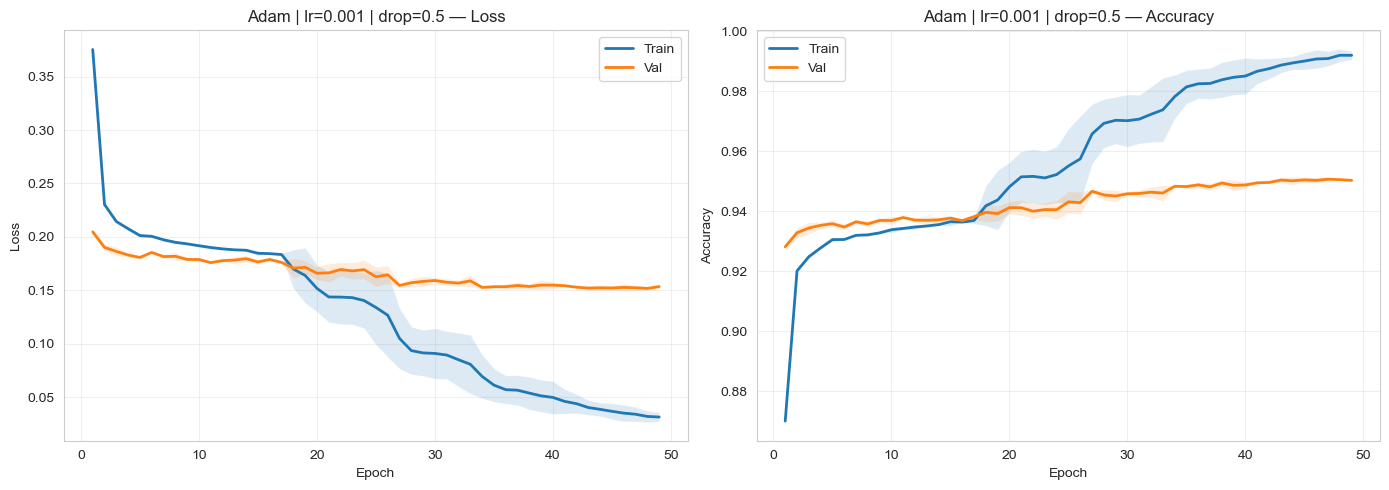

In [9]:
# Grid Search K-Fold — Optimizer × LR × Dropout

class DNNGrid(nn.Module):
    """256 → 128 → classes (LeakyReLU, dropout parameterizado)""" 
    def __init__(self, input_size, num_classes, drop=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.1), nn.Dropout(drop),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.LeakyReLU(0.1), nn.Dropout(drop),
            nn.Linear(128, num_classes))
    def forward(self, x): return self.net(x)


def train_grid(model, X_tr, y_tr, X_vl, y_vl,
               opt_name='Adam', lr=0.001, wd=1e-3, epochs=100, patience=10, bs=256):
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    if opt_name == 'Adam':
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif opt_name == 'AdamW':
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    else:
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=5)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=bs, shuffle=True)
    best_vl = float('inf'); wait = 0; best_st = None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for ep in range(epochs):
        model.train()
        ep_loss = 0; ep_correct = 0; ep_total = 0
        for bx, by in loader:
            opt.zero_grad()
            out = model(bx)
            loss = crit(out, by)
            loss.backward(); opt.step()
            ep_loss += loss.item() * bx.size(0)
            ep_correct += (torch.argmax(out, 1) == by).sum().item()
            ep_total += bx.size(0)
        history['train_loss'].append(ep_loss / ep_total)
        history['train_acc'].append(ep_correct / ep_total)
        model.eval()
        with torch.no_grad():
            val_out = model(X_vl)
            vl = crit(val_out, y_vl).item()
            va = (torch.argmax(val_out, 1) == y_vl).float().mean().item()
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        sched.step(vl)
        if vl < best_vl:
            best_vl = vl; wait = 0
            best_st = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_st: model.load_state_dict(best_st)
    model.eval()
    with torch.no_grad():
        final_acc = (torch.argmax(model(X_vl), 1) == y_vl).float().mean().item()
    return final_acc, history

# Grid Search com K-Fold e tempo estimado
optimizers = ['Adam', 'AdamW', 'SGD']
lrs = [0.01, 0.001, 0.0001]
dropouts = [0.3, 0.5, 0.7]

configs = [(o, l, d) for o in optimizers for l in lrs for d in dropouts]
total_configs = len(configs)
total_runs = total_configs * K

print(f"Grid Search {K}-Fold — {total_configs} configs × {K} folds = {total_runs} treinos")

results = []
global_start = time.time()
run_count = 0

for cfg_idx, (opt_name, lr, drop) in enumerate(configs):
    config_str = f'{opt_name} | lr={lr} | drop={drop}'
    accs = []; all_hist = []
    
    for fold, (tr_i, vl_i) in enumerate(stratified_k_fold(labels, K)):
        run_count += 1
        t_tr = [textos[i] for i in tr_i]; t_vl = [textos[i] for i in vl_i]
        l_tr = [labels[i] for i in tr_i]; l_vl = [labels[i] for i in vl_i]
        X_tr, _, X_vl, _, _, _ = prepare_fold_data(t_tr, l_tr, t_vl, l_vl, **FEAT_PARAMS)
        y_tr = np.array([class_names_list.index(l) for l in l_tr])
        y_vl = np.array([class_names_list.index(l) for l in l_vl])
        
        torch.manual_seed(42)
        model = DNNGrid(X_tr.shape[1], num_classes, drop=drop)
        acc, hist = train_grid(model,
            torch.FloatTensor(X_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.FloatTensor(X_vl).to(device), torch.LongTensor(y_vl).to(device),
            opt_name=opt_name, lr=lr, patience=15, bs=256)
        accs.append(acc); all_hist.append(hist)
    
    mean_acc = np.mean(accs); std_acc = np.std(accs)
    results.append({'config': config_str, 'mean': mean_acc, 'std': std_acc,
                    'accs': accs, 'histories': all_hist,
                    'opt': opt_name, 'lr': lr, 'drop': drop})
    
    # Tempo decorrido e estimativa 
    elapsed = time.time() - global_start
    avg_per_run = elapsed / run_count
    remaining_runs = total_runs - run_count
    eta = avg_per_run * remaining_runs
    
    elapsed_min = elapsed / 60
    eta_min = eta / 60
    
    print(f'  [{cfg_idx+1:2d}/{total_configs}] {config_str}  →  '
          f'{mean_acc:.2%} ± {std_acc:.2%}  '
          f'[⏱ {elapsed_min:.1f}min | ETA: {eta_min:.1f}min]')

# Ranking final
results.sort(key=lambda x: x['mean'], reverse=True)
total_time = (time.time() - global_start) / 60

print(f'  Ranking TOP 10  (tempo total: {total_time:.1f} min)')
for i, r in enumerate(results[:10]):
    marker = ' 🏆' if i == 0 else ''
    print(f'  {i+1:2d}. {r["config"]}  →  {r["mean"]:.2%} ± {r["std"]:.2%}{marker}')

# Plot
best = results[0]
print(f'\n✅ Melhor: {best["config"]} ({best["mean"]:.2%} ± {best["std"]:.2%})')

min_len = min(len(h['train_loss']) for h in best['histories'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (tk, vk), ax, title in [
    (('train_loss', 'val_loss'), axes[0], 'Loss'),
    (('train_acc', 'val_acc'), axes[1], 'Accuracy')
]:
    t_vals = np.array([h[tk][:min_len] for h in best['histories']])
    v_vals = np.array([h[vk][:min_len] for h in best['histories']])
    epochs_range = range(1, min_len + 1)
    ax.plot(epochs_range, t_vals.mean(axis=0), label='Train', linewidth=2)
    ax.plot(epochs_range, v_vals.mean(axis=0), label='Val', linewidth=2)
    ax.fill_between(epochs_range,
                    t_vals.mean(0) - t_vals.std(0),
                    t_vals.mean(0) + t_vals.std(0), alpha=0.15)
    ax.fill_between(epochs_range,
                    v_vals.mean(0) - v_vals.std(0),
                    v_vals.mean(0) + v_vals.std(0), alpha=0.15)
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.set_title(f'{best["config"]} — {title}')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Guardar o melhor no cv_results para a tabela final
cv_results[f'Grid Best: {best["config"]}'] = np.array(best['accs'])


In [10]:
# import pickle

# # Guardar o dicionário cv_results e a lista results num ficheiro
# estado_atual = {
#     'cv_results': cv_results,
#     'grid_results': results
# }

# with open('backup_trabalho_dl.pkl', 'wb') as f:
#     pickle.dump(estado_atual, f)

# print("✅ Estado guardado com sucesso! Já podes fechar o notebook.")

In [11]:
# import pickle

# with open('backup_trabalho_dl.pkl', 'rb') as f:
#     estado_recuperado = pickle.load(f)
    
# cv_results = estado_recuperado['cv_results']
# results = estado_recuperado['grid_results']

# print(f"Recuperados {len(cv_results)} modelos iniciais!")
# print(f"Recuperadas {len(results)} iterações da Grid Search!")

### **5. Retreino e Avaliação de TODOS os Modelos no Dataset de Teste**

Cada modelo é retreinado com split 80/20 (para early stopping) e avaliado
no dataset de teste externo. Temos assim **validação** (K-Fold) e **teste**
(dataset independente) para todos os modelos.

In [12]:
# Preparar dados uma só vez — tabulares e sequências

# --- TABULARES (TF-IDF) ---
from sklearn.model_selection import train_test_split as sk_split

X_train, Y_train_oh, X_val, Y_val_oh, transformers, encoder = prepare_text_data(
    textos, labels, max_features=3000, char_features=2000, val_size=0.20,
    use_stratify=True, ngram_range=(1, 2), stop_words=set())
X_test_tab = transform_new_texts(textos_test, transformers)
y_train_tab = np.argmax(Y_train_oh, axis=1)
y_val_tab = np.argmax(Y_val_oh, axis=1)
y_test_tab = np.argmax(encoder.transform(np.array(labels_test)), axis=1)
class_names = encoder.classes
input_size = X_train.shape[1]

X_tr_t = torch.FloatTensor(X_train).to(device)
y_tr_t = torch.LongTensor(y_train_tab).to(device)
X_vl_t = torch.FloatTensor(X_val).to(device)
y_vl_t = torch.LongTensor(y_val_tab).to(device)
X_te_t = torch.FloatTensor(X_test_tab).to(device)
y_te_t = torch.LongTensor(y_test_tab).to(device)

# --- SEQUÊNCIAS (tokenizadas) ---
t_tr_seq, t_vl_seq, l_tr_seq, l_vl_seq = sk_split(
    textos, labels, test_size=0.20, random_state=42, stratify=labels)
word2idx = build_fold_vocab(t_tr_seq)
actual_vocab_size = len(word2idx)
s_tr = texts_to_sequences(t_tr_seq, word2idx, MAX_SEQ_LEN)
s_vl = texts_to_sequences(t_vl_seq, word2idx, MAX_SEQ_LEN)
s_te = texts_to_sequences(textos_test, word2idx, MAX_SEQ_LEN)
y_tr_seq = np.array([class_names_list.index(l) for l in l_tr_seq])
y_vl_seq = np.array([class_names_list.index(l) for l in l_vl_seq])
y_te_seq = np.array([class_names_list.index(l) for l in labels_test])

s_tr_t = torch.LongTensor(s_tr).to(device); y_trs_t = torch.LongTensor(y_tr_seq).to(device)
s_vl_t = torch.LongTensor(s_vl).to(device); y_vls_t = torch.LongTensor(y_vl_seq).to(device)
s_te_t = torch.LongTensor(s_te).to(device); y_tes_t = torch.LongTensor(y_te_seq).to(device)

# GloVe embedding matrix
emb_matrix, glove_found = build_emb_matrix(word2idx, glove_all, GLOVE_DIM)
print(f'  GloVe: {glove_found}/{actual_vocab_size-2} palavras encontradas')

print(f'  Tabular — Treino: {X_train.shape} | Val: {X_val.shape} | Teste: {X_test_tab.shape}')
print(f'  Sequência — Treino: {s_tr.shape} | Val: {s_vl.shape} | Teste: {s_te.shape}')

  GloVe: 27143/29998 palavras encontradas
  Tabular — Treino: (98270, 5013) | Val: (24565, 5013) | Teste: (475, 5013)
  Sequência — Treino: (98268, 150) | Val: (24567, 150) | Teste: (475, 150)


In [13]:
# Retreinar e avaliar TODOS os modelos no teste
resultados_todos = {}

def eval_model(model, X, y,bs=256):
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for bx, by in DataLoader(TensorDataset(X, y), batch_size=bs, shuffle=False):
            correct += (torch.argmax(model(bx), 1) == by).sum().item()
            total += bx.size(0)
    return correct / total

# --- DNNs tabulares ---
tab_map = {
    'DNN Wide (256→128)':           lambda: DNNWide(input_size, num_classes),
    'DNN Narrow (128→64)':          lambda: DNNNarrow(input_size, num_classes),
    'DNN Deep (256→128→64)':        lambda: DNNDeep(input_size, num_classes),
    'DNN Simple (128→32)':          lambda: DNNSimple(input_size, num_classes),
    'DNN VeryDeep (256→128→64→32)': lambda: DNNVeryDeep(input_size, num_classes),
    'DNN LeakyReLU (256→128)':      lambda: DNNLeakyReLU(input_size, num_classes),
    'DNN ELU (256→128)':            lambda: DNNELU(input_size, num_classes),
}

for nome, fn in tab_map.items():
    print(f'\n{"="*60}\n{nome}\n{"="*60}')
    torch.manual_seed(42)
    model = fn()
    t0 = time.time()
    _, _ = train_pytorch(model, X_tr_t, y_tr_t, X_vl_t, y_vl_t, patience=10)
    tempo = time.time() - t0
    train_acc = eval_model(model, X_tr_t, y_tr_t)
    val_acc = eval_model(model, X_vl_t, y_vl_t)
    test_acc = eval_model(model, X_te_t, y_te_t)
    resultados_todos[nome] = {
        'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc,
        'tempo': tempo, 'modelo': model, 'test_input': X_te_t, 'test_labels': y_te_t
    }
    print(f'  Treino: {train_acc:.2%} | Val: {val_acc:.2%} | Teste: {test_acc:.2%} | {tempo:.1f}s')

# --- Grid Search Best ---
if results:
    best_grid = results[0]
    nome_grid = f'Grid Best: {best_grid["config"]}'
    print(f'\n{"="*60}\n{nome_grid}\n{"="*60}')
    torch.manual_seed(42)
    model = DNNGrid(input_size, num_classes, drop=best_grid['drop'])
    t0 = time.time()
    _, _ = train_grid(model, X_tr_t, y_tr_t, X_vl_t, y_vl_t,
                      opt_name=best_grid['opt'], lr=best_grid['lr'], patience=15)
    tempo = time.time() - t0
    train_acc = eval_model(model, X_tr_t, y_tr_t)
    val_acc = eval_model(model, X_vl_t, y_vl_t)
    test_acc = eval_model(model, X_te_t, y_te_t)
    resultados_todos[nome_grid] = {
        'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc,
        'tempo': tempo, 'modelo': model, 'test_input': X_te_t, 'test_labels': y_te_t
    }
    print(f'  Treino: {train_acc:.2%} | Val: {val_acc:.2%} | Teste: {test_acc:.2%} | {tempo:.1f}s')

# --- Embedding+DNN ---
seq_cfgs = {
    'Embed+DNN (128d)': lambda: EmbeddingDNN(actual_vocab_size, 128, num_classes),
    'Embed+DNN (256d)': lambda: EmbeddingDNN(actual_vocab_size, 256, num_classes),
    'BiLSTM (h=128)':   lambda: BiLSTM(actual_vocab_size, 128, 128, num_classes),
    'BiLSTM (h=256)':   lambda: BiLSTM(actual_vocab_size, 128, 256, num_classes),
    'BiGRU (h=128)':    lambda: BiGRU(actual_vocab_size, 128, 128, num_classes),
    'BiGRU (h=256)':    lambda: BiGRU(actual_vocab_size, 128, 256, num_classes),
}

for nome, fn in seq_cfgs.items():
    print(f'\n{"="*60}\n{nome}\n{"="*60}')
    torch.manual_seed(42)
    model = fn()
    t0 = time.time()
    _, _ = train_pytorch(model, s_tr_t, y_trs_t, s_vl_t, y_vls_t, wd=1e-4, patience=10)
    tempo = time.time() - t0
    train_acc = eval_model(model, s_tr_t, y_trs_t)
    val_acc = eval_model(model, s_vl_t, y_vls_t)
    test_acc = eval_model(model, s_te_t, y_tes_t)
    resultados_todos[nome] = {
        'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc,
        'tempo': tempo, 'modelo': model, 'test_input': s_te_t, 'test_labels': y_tes_t
    }
    print(f'  Treino: {train_acc:.2%} | Val: {val_acc:.2%} | Teste: {test_acc:.2%} | {tempo:.1f}s')

# --- BiLSTM+GloVe ---
for nome, freeze in [('BiLSTM+GloVe (frozen)', True), ('BiLSTM+GloVe (fine-tuned)', False)]:
    print(f'\n{"="*60}\n{nome}\n{"="*60}')
    torch.manual_seed(42)
    model = BiLSTMGloVe(emb_matrix, GLOVE_HIDDEN, num_classes, freeze_embed=freeze)
    t0 = time.time()
    _, _ = train_pytorch(model, s_tr_t, y_trs_t, s_vl_t, y_vls_t, wd=1e-4, patience=15, bs=256)
    tempo = time.time() - t0
    train_acc = eval_model(model, s_tr_t, y_trs_t)
    val_acc = eval_model(model, s_vl_t, y_vls_t)
    test_acc = eval_model(model, s_te_t, y_tes_t)
    resultados_todos[nome] = {
        'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc,
        'tempo': tempo, 'modelo': model, 'test_input': s_te_t, 'test_labels': y_tes_t
    }
    print(f'  Treino: {train_acc:.2%} | Val: {val_acc:.2%} | Teste: {test_acc:.2%} | {tempo:.1f}s')

print('\n✅ Todos os modelos treinados e avaliados.')


DNN Wide (256→128)
  Treino: 99.98% | Val: 95.36% | Teste: 73.89% | 105.0s

DNN Narrow (128→64)
  Treino: 99.84% | Val: 95.14% | Teste: 74.32% | 84.4s

DNN Deep (256→128→64)
  Treino: 99.70% | Val: 95.05% | Teste: 75.37% | 89.8s

DNN Simple (128→32)
  Treino: 97.28% | Val: 94.66% | Teste: 72.21% | 87.0s

DNN VeryDeep (256→128→64→32)
  Treino: 99.46% | Val: 94.84% | Teste: 72.00% | 110.9s

DNN LeakyReLU (256→128)
  Treino: 99.92% | Val: 95.21% | Teste: 73.68% | 106.1s

DNN ELU (256→128)
  Treino: 97.10% | Val: 94.43% | Teste: 74.11% | 105.3s

Grid Best: Adam | lr=0.001 | drop=0.5
  Treino: 99.98% | Val: 95.35% | Teste: 75.16% | 95.6s

Embed+DNN (128d)
  Treino: 96.82% | Val: 91.19% | Teste: 74.95% | 41.7s

Embed+DNN (256d)
  Treino: 96.60% | Val: 91.15% | Teste: 76.00% | 47.1s

BiLSTM (h=128)
  Treino: 99.19% | Val: 94.68% | Teste: 73.68% | 260.2s

BiLSTM (h=256)
  Treino: 98.30% | Val: 94.39% | Teste: 73.68% | 436.8s

BiGRU (h=128)
  Treino: 99.23% | Val: 94.94% | Teste: 76.21% | 184.

### **5.1 Tabela Comparativa — Validação (K-Fold) vs Teste**

In [14]:
# Tabela comparativa: K-Fold CV vs Teste
rows = []
for nome in resultados_todos:
    r = resultados_todos[nome]
    if nome in cv_results:
        kfold_mean = cv_results[nome].mean()
        kfold_std = cv_results[nome].std()
        kf_str = f'{kfold_mean:.2%} ±{kfold_std:.2%}'
    else:
        kf_str = '—'
    rows.append({
        'Modelo': nome,
        'K-Fold (média±std)': kf_str,
        'Treino': f'{r["train_acc"]:.2%}',
        'Validação (20%)': f'{r["val_acc"]:.2%}',
        'Teste': f'{r["test_acc"]:.2%}',
        'Tempo (s)': f'{r["tempo"]:.1f}'
    })

df_comp = pd.DataFrame(rows).sort_values('Teste', ascending=False)
print('Comparação Validação vs Teste — Todos os Modelos:\n')
print(df_comp.to_string(index=False))

melhor_nome = df_comp.iloc[0]['Modelo']
print(f'\n🏆 Melhor modelo no teste: {melhor_nome} — {resultados_todos[melhor_nome]["test_acc"]:.2%}')

Comparação Validação vs Teste — Todos os Modelos:

                               Modelo K-Fold (média±std) Treino Validação (20%)  Teste Tempo (s)
                        BiGRU (h=256)      94.72% ±0.13% 98.89%          95.03% 76.84%     423.6
                        BiGRU (h=128)      94.49% ±0.11% 99.23%          94.94% 76.21%     184.2
                     Embed+DNN (256d)      90.69% ±0.12% 96.60%          91.15% 76.00%      47.1
            BiLSTM+GloVe (fine-tuned)      93.40% ±0.06% 98.47%          93.85% 75.79%     223.1
                DNN Deep (256→128→64)      94.69% ±0.06% 99.70%          95.05% 75.37%      89.8
Grid Best: Adam | lr=0.001 | drop=0.5      95.00% ±0.16% 99.98%          95.35% 75.16%      95.6
                     Embed+DNN (128d)      90.90% ±0.24% 96.82%          91.19% 74.95%      41.7
                BiLSTM+GloVe (frozen)      93.78% ±0.17% 98.31%          94.15% 74.74%     474.9
                  DNN Narrow (128→64)      94.68% ±0.07% 99.84%          95.

### **6. Avaliação Final — Confusion Matrix e Classification Report (Todos os Modelos)**

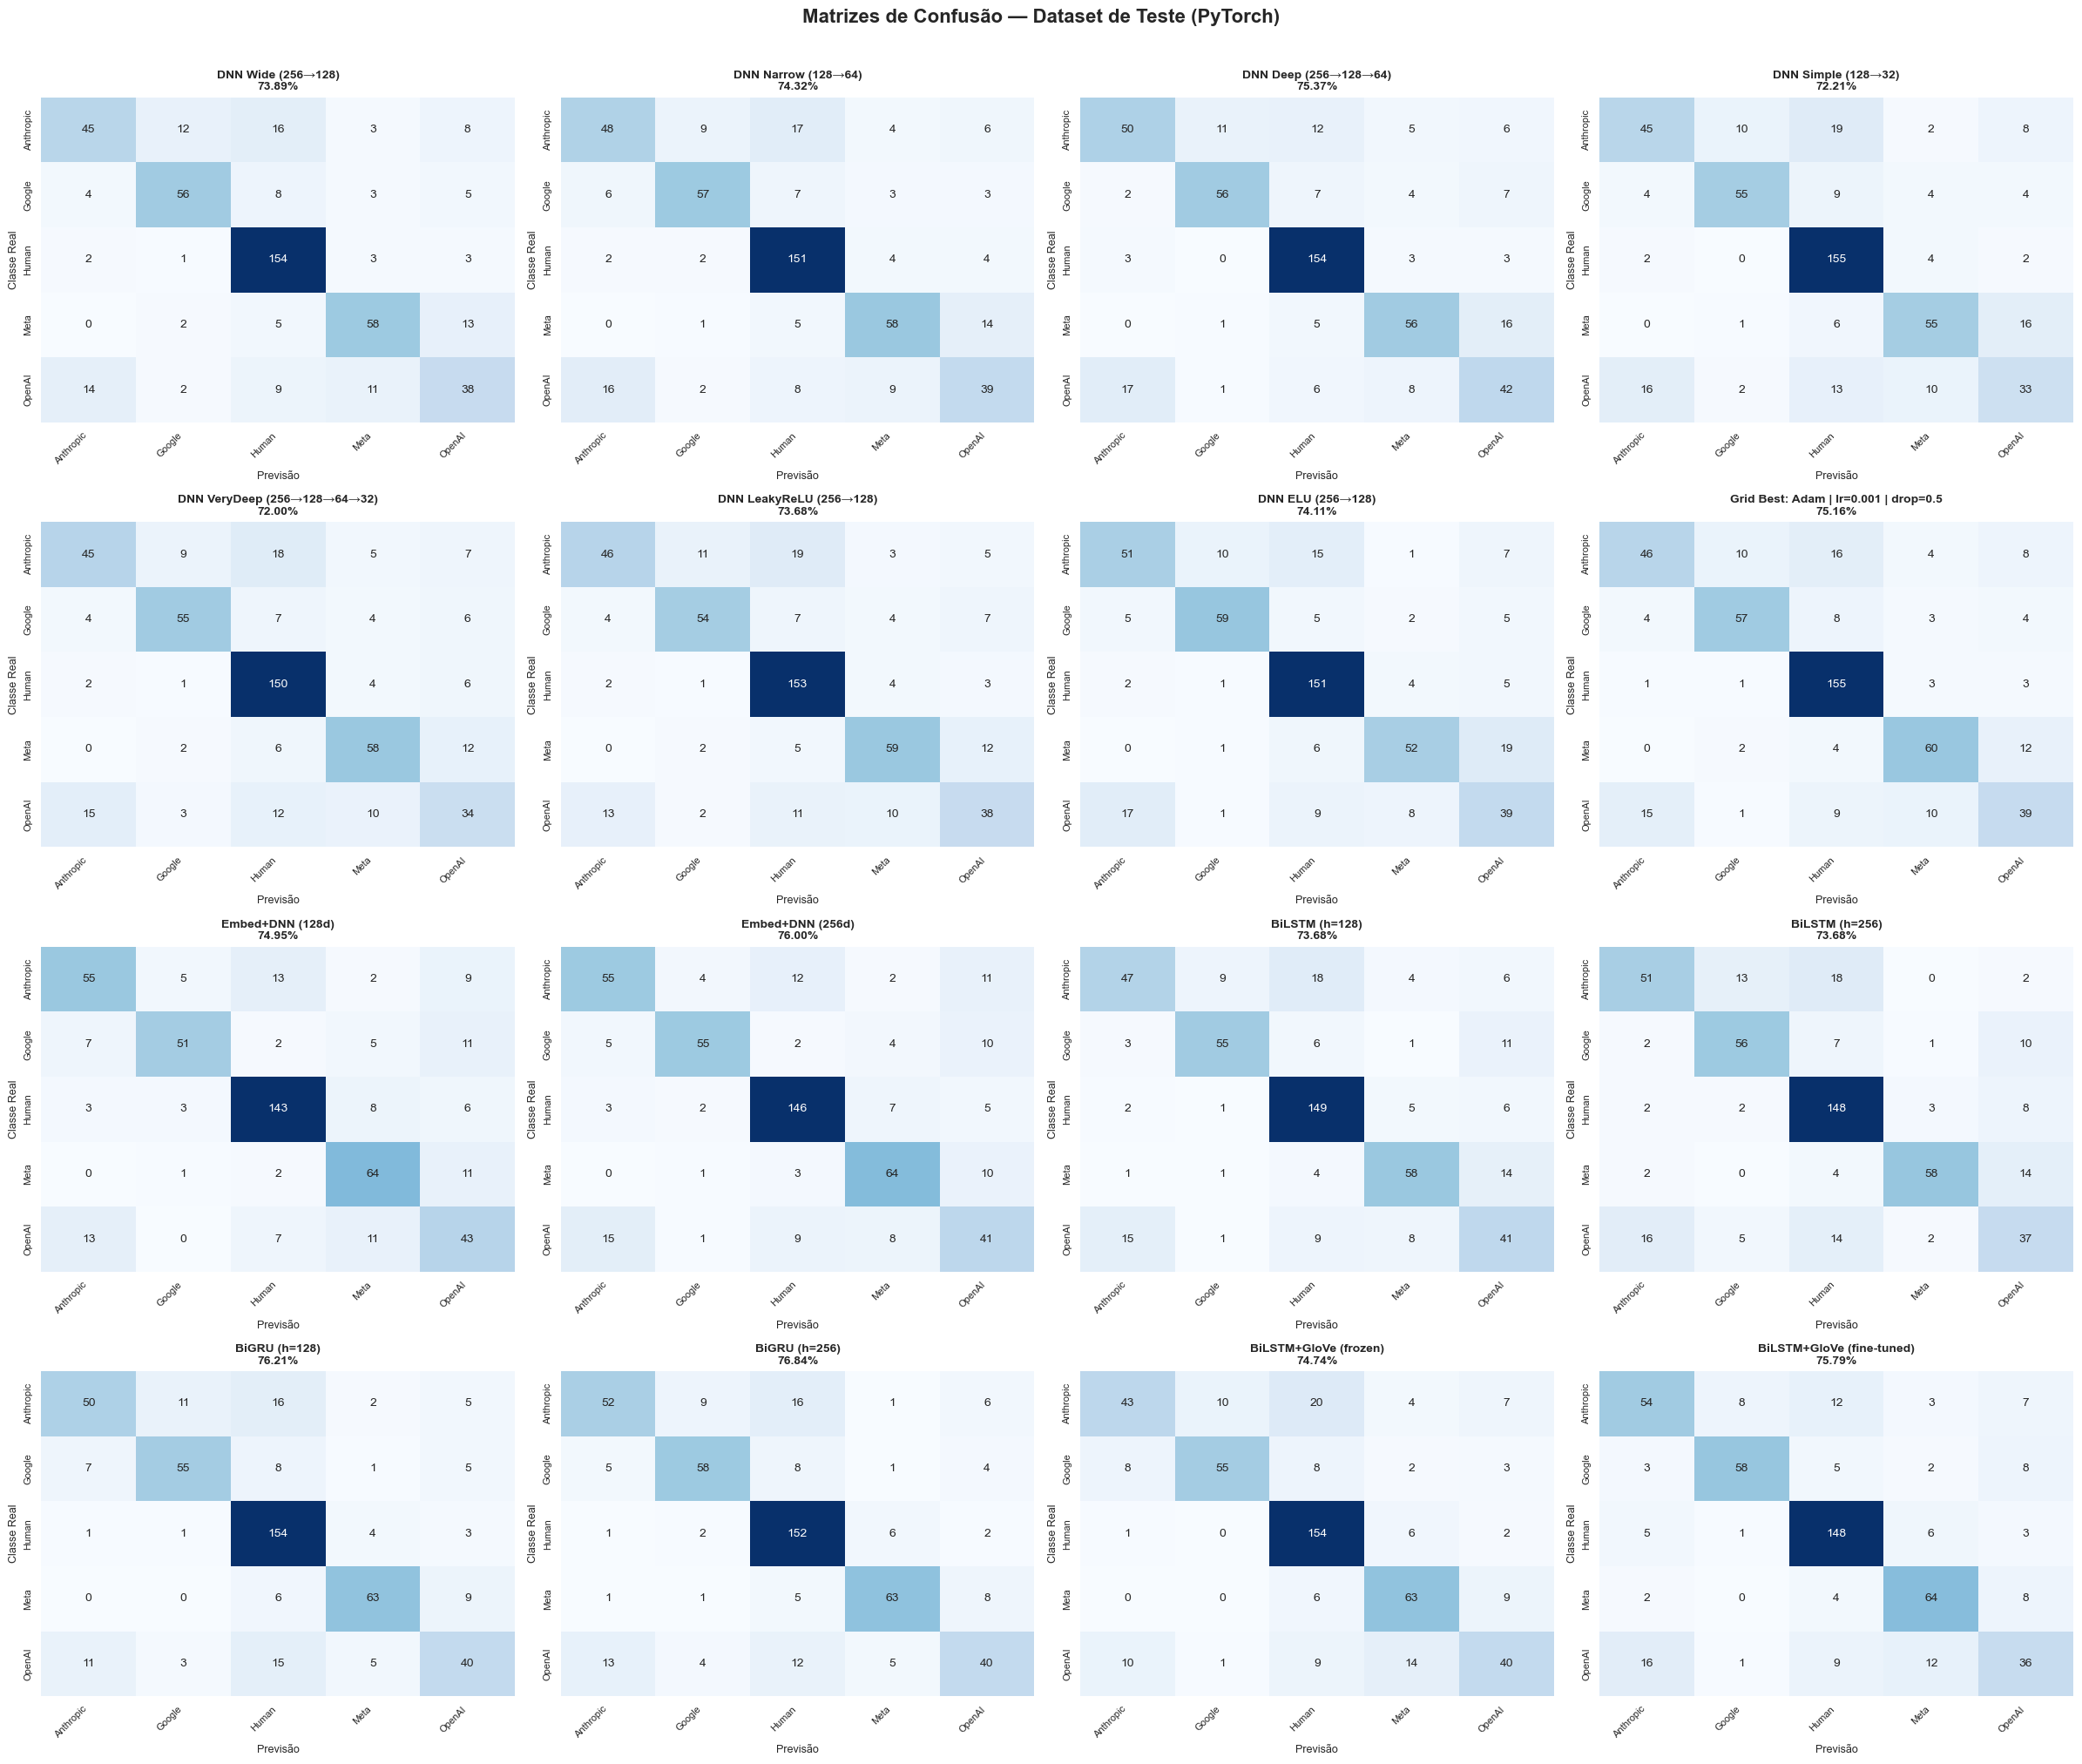

In [15]:
y_true_test = y_te_t.cpu().numpy()  # fallback para tabulares

n_modelos = len(resultados_todos)
n_cols = 4
n_rows = (n_modelos + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for idx, (nome, r) in enumerate(resultados_todos.items()):
    modelo = r['modelo']; modelo.eval()
    ti = r['test_input']; tl = r['test_labels']
    with torch.no_grad():
        y_pred = torch.argmax(modelo(ti), 1).cpu().numpy()
    y_true = tl.cpu().numpy()
    cm = confusion_matrix(y_true, y_pred)
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                cbar=False)
    ax.set_xlabel('Previsão', fontsize=9)
    ax.set_ylabel('Classe Real', fontsize=9)
    ax.set_title(f'{nome}\n{r["test_acc"]:.2%}', fontweight='bold', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrizes de Confusão — Dataset de Teste (PyTorch)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# Classification Reports para todos os modelos
for nome, r in resultados_todos.items():
    modelo = r['modelo']; modelo.eval()
    ti = r['test_input']; tl = r['test_labels']
    with torch.no_grad():
        y_pred = torch.argmax(modelo(ti), 1).cpu().numpy()
    y_true = tl.cpu().numpy()
    print(f'\n{"="*60}')
    print(f'Classification Report — {nome} (Teste: {r["test_acc"]:.2%})')
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


Classification Report — DNN Wide (256→128) (Teste: 73.89%)
              precision    recall  f1-score   support

   Anthropic       0.69      0.54      0.60        84
      Google       0.77      0.74      0.75        76
       Human       0.80      0.94      0.87       163
        Meta       0.74      0.74      0.74        78
      OpenAI       0.57      0.51      0.54        74

    accuracy                           0.74       475
   macro avg       0.71      0.69      0.70       475
weighted avg       0.73      0.74      0.73       475


Classification Report — DNN Narrow (128→64) (Teste: 74.32%)
              precision    recall  f1-score   support

   Anthropic       0.67      0.57      0.62        84
      Google       0.80      0.75      0.78        76
       Human       0.80      0.93      0.86       163
        Meta       0.74      0.74      0.74        78
      OpenAI       0.59      0.53      0.56        74

    accuracy                           0.74       475
   macro a

### **7. Guardar o Melhor Modelo**

In [17]:
import pickle

melhor_r = resultados_todos[melhor_nome]
melhor_model = melhor_r['modelo']

os.makedirs('../models', exist_ok=True)
torch.save(melhor_model.state_dict(), '../models/pytorch.pth')

meta = {
    'model_class': melhor_model.__class__.__name__,
    'input_size': input_size,
    'num_classes': num_classes,
    'class_names': list(class_names),
    'transformers': transformers,
    'encoder': encoder,
    'test_acc': melhor_r['test_acc'],
}

# Hiperparâmetros do Grid Search
is_grid = melhor_nome.startswith('Grid Best:')
if is_grid:
    for r in results:
        if r['config'] in melhor_nome:
            meta['grid_opt'] = r['opt']
            meta['grid_lr'] = r['lr']
            meta['grid_drop'] = r['drop']
            break

# Modelos de sequência
is_tabular = melhor_nome in tab_map or is_grid
if not is_tabular:
    meta['word2idx'] = word2idx
    meta['max_seq_len'] = MAX_SEQ_LEN
    meta['vocab_size'] = actual_vocab_size
    if 'GloVe' in melhor_nome:
        meta['embed_dim'] = GLOVE_DIM
        meta['hidden_dim'] = GLOVE_HIDDEN
        meta['embedding_matrix'] = emb_matrix
        meta['freeze_embed'] = 'frozen' in melhor_nome
    elif 'Embed' in melhor_nome:
        meta['embed_dim'] = 256 if '256' in melhor_nome else 128
    else:
        meta['embed_dim'] = 128
        meta['hidden_dim'] = 256 if '256' in melhor_nome else 128

with open('../models/pytorch.pkl', 'wb') as f:
    pickle.dump(meta, f)
print(f'✅ Modelo guardado: {meta["model_class"]}')
print(f'   Teste Acc: {melhor_r["test_acc"]:.2%}')

✅ Modelo guardado: BiGRU
   Teste Acc: 76.84%
